In [1]:
import time
import torch
import os
import IPython.display as display

if not hasattr(display, "set_matplotlib_formats"):
    # no-op fallback (or you can force retina/png instead)
    def set_matplotlib_formats(*args, **kwargs):
        return None
    display.set_matplotlib_formats = set_matplotlib_formats

from d2l.torch import Animator

from net import Net
from utils import load_val_dataset
from faco import MFACO_CVRP

from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
PRETRAINED_DIR = PROJECT_ROOT / "../pretrained"

# Optional wandb logging (lazy import to avoid hangs at import-time)
USE_WANDB = True
WANDB_PROJECT = os.environ.get("WANDB_PROJECT", "claco")
WANDB_ENTITY = os.environ.get("WANDB_ENTITY") or None
WANDB_MODE = os.environ.get("WANDB_MODE", "online")  # set to "offline" to avoid network
wandb = None

def _wandb_init(config: dict, name: str | None = None):
    """Init a fresh wandb run for each train() call.

    In notebooks it's common to re-run the train cell; reusing the same wandb run
    causes non-monotonic step warnings when we log with an explicit `step=`.
    """
    global wandb, USE_WANDB
    if not USE_WANDB:
        return None
    if wandb is None:
        try:
            import wandb as _wandb
            wandb = _wandb
        except Exception as e:
            USE_WANDB = False
            print("wandb disabled (import failed):", e)
            return None
    if wandb.run is not None:
        # Start a new run to avoid step going backwards on re-runs.
        try:
            wandb.finish()
        except Exception:
            pass
    return wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        config=config,
        name=name,
        mode=WANDB_MODE,
    )

torch.manual_seed(1234)

lr = 1e-4
H=10
mini_H=100
rho = 0.5
min_new_edges = 16
disable_heuristic = False
use_local_search = True
smooth_mmas = True
extend_ls = True
normalize_heuristic = True
no_logit_net = False
no_dynamic_feats = False
k_sparse = 32
n_ants = 100
steps_per_epoch = 32
epochs = 10

device = 'cuda:0'

# Import your compiled extension (needed for get_max_threads print below)
try:
    import faco_cvrp
except Exception as e:
    faco_cvrp = None
    print("Warning: could not import faco_cvrp:", e)

if faco_cvrp is not None:
    print("faco_cvrp imported. OpenMP max threads:", faco_cvrp.get_max_threads())

/home/shora/Research/old/NGFACO/data
faco_cvrp imported. OpenMP max threads: 10


In [2]:
# Import training logic from train.py (keep notebook focused on experiments/plots)
from types import SimpleNamespace
import train as train_mod
from tqdm.notebook import tqdm as notebook_tqdm
from functools import partial

# Patch the tqdm symbol used inside train.py
train_mod.tqdm = partial(notebook_tqdm, disable=True)


# Re-export helpers if you still want to inspect/DEBUG them in notebook
_popcount_i64 = train_mod._popcount_i64
replay_logp_from_cpp_batch_trace = train_mod.replay_logp_from_cpp_batch_trace
train_instance = train_mod.train_instance
train_epoch_core = train_mod.train_epoch
validation_core = train_mod.validation


def _make_args(n_node, k_sparse, n_ants, steps_per_epoch, *, H, mini_H, device,
              rho=0.1, min_new_edges=8,
              disable_heuristic=True,
              use_local_search=True,
              smooth_mmas=False,
              extend_ls=False,
              normalized_heuristic=False,
              debug=False,
              use_wandb=False,
              no_logit_net=False,
              baseline='none', baseline_runs=1, baseline_time_limit=10.0):
    """Create a train.py-compatible args namespace from notebook globals."""
    return SimpleNamespace(
        # problem / graph
        n_node=int(n_node),
        k_sparse=int(k_sparse),
        n_ants=int(n_ants),
        steps_per_epoch=int(steps_per_epoch),
        epochs=None,
        lr=lr,
        seed=1234,
        device=str(device),

        # aco
        rho=float(rho),
        min_new_edges=int(min_new_edges),
        H=int(H),
        mini_H=int(mini_H),
        disable_heuristic=bool(disable_heuristic),
        no_local_search=not bool(use_local_search),
        no_smooth_mmas=not bool(smooth_mmas),
        extend_ls=bool(extend_ls),
        no_normalized_heuristic=not bool(normalized_heuristic),
        debug=bool(debug),
        no_logit_net=bool(no_logit_net),

        # logging
        no_wandb=not bool(use_wandb),
        wandb_project=WANDB_PROJECT,
        wandb_entity=WANDB_ENTITY,
        save_dir=str(PRETRAINED_DIR / 'cvrp'),
        no_dynamic_feats=no_dynamic_feats,

        # baseline (validation)
        baseline=str(baseline),
        baseline_runs=int(baseline_runs),
        baseline_time_limit=float(baseline_time_limit),
    )


@torch.no_grad()
def validation(n_ants, epoch, net, val_dataset, k_sparse, animator, dynamic, args, baseline_values=None):
    """Notebook wrapper around train.py validation (keeps the old Animator plotting style)."""
    avg_last, avg_best, _gap = validation_core(
        args=args,
        epoch=epoch,
        net=net,
        val_dataset=val_dataset,
        dynamic=dynamic,
        baseline_values=baseline_values,
    )
    if animator is not None:
        animator.add(epoch + 1, (avg_last, avg_best))
    return avg_last, avg_best


def train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, dynamic,
          *,
          H=H,
          mini_H=mini_H,
          rho=rho,
          min_new_edges=min_new_edges,
          disable_heuristic=disable_heuristic,
          use_local_search=use_local_search,
          smooth_mmas=smooth_mmas,
          extend_ls=extend_ls,
          normalized_heuristic=normalize_heuristic,
          debug=False,
          use_wandb=USE_WANDB,
          no_logit_net=no_logit_net,
          baseline='hgs',
          baseline_runs=1,
          baseline_time_limit=0.5,
          baseline_values=None,
          ):

    args = _make_args(
        n_node=n_node,
        k_sparse=k_sparse,
        n_ants=n_ants,
        steps_per_epoch=steps_per_epoch,
        H=H,
        mini_H=mini_H,
        device=device,
        rho=rho,
        min_new_edges=min_new_edges,
        disable_heuristic=disable_heuristic,
        use_local_search=use_local_search,
        smooth_mmas=smooth_mmas,
        extend_ls=extend_ls,
        normalized_heuristic=normalized_heuristic,
        debug=debug,
        use_wandb=use_wandb,
        no_logit_net=no_logit_net,
        baseline=baseline,
        baseline_runs=baseline_runs,
        baseline_time_limit=baseline_time_limit,
    )

    # (Optional) wandb init: keep the notebook helper, but make train.py see the same module
    run = None
    if use_wandb:
        run = _wandb_init(config=vars(args), name=f"cvrp{n_node}")
        # make sure train.py logs to the same wandb module
        try:
            import wandb as _wb
            train_mod.wandb = _wb
            args.no_wandb = False
        except Exception as e:
            print('wandb disabled (import failed):', e)
            args.no_wandb = True

    net = Net(logit_net=not no_logit_net).to(device)
    optimizer = torch.optim.AdamW(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs, eta_min=lr * 0.1)

    val_list = load_val_dataset(n_node, device)
    animator = Animator(xlabel='epoch', xlim=[0, epochs], legend=["Avg. sample obj.", "Best ACO obj."])

    avg_last, avg_aco_best = validation(n_ants, -1, net, val_list, k_sparse, animator, dynamic, args, baseline_values=baseline_values)
    val_results = [(avg_last, avg_aco_best)]

    global_step = 0
    sum_time = 0
    best_val = float('inf')

    for epoch in range(0, epochs):
        start = time.time()
        global_step, _train_avg_cost = train_epoch_core(args, epoch, net, optimizer, global_step, dynamic=dynamic)
        scheduler.step()
        sum_time += time.time() - start

        avg_last, avg_aco_best = validation(n_ants, epoch, net, val_list, k_sparse, animator, dynamic, args, baseline_values=baseline_values)
        val_results.append((avg_last, avg_aco_best))

        if avg_aco_best < best_val:
            best_val = avg_aco_best
            os.makedirs(PRETRAINED_DIR / 'cvrp', exist_ok=True)
            torch.save(net.state_dict(), f"{PRETRAINED_DIR}/cvrp/cvrp{n_node}.pt")

    print('total training duration:', sum_time)

    for epoch in range(-1, epochs):
        print(f'epoch {epoch}:', val_results[epoch + 1])

    if use_wandb and run is not None:
        try:
            import wandb as _wb
            _wb.finish()
        except Exception:
            pass



Learn heuristic for TSP100: 

wandb: updating run metadata


total training duration: 1193.7100377082825
epoch -1: (53.56494164466858, 51.86996507644653)
epoch 0: (53.358519554138184, 51.960914611816406)
epoch 1: (53.40339207649231, 51.94976830482483)
epoch 2: (53.10588455200195, 51.714452505111694)
epoch 3: (52.75083780288696, 51.56420016288757)
epoch 4: (52.58620285987854, 51.416550159454346)
epoch 5: (52.291377544403076, 51.276992321014404)
epoch 6: (52.28643345832825, 51.19101047515869)
epoch 7: (52.22800397872925, 51.22158408164978)
epoch 8: (52.09439945220947, 51.136167764663696)
epoch 9: (51.96351909637451, 51.00514531135559)


wandb: uploading wandb-summary.json


wandb: uploading history steps 318-319, summary


wandb: 
wandb: Run history:
wandb:  train/avg_cost ▆▄▄▅▆▅▆▆▃▇▃▃▃▄▂▅▅█▅▃▁▄▂▁▄▄▂▄▅▄▆▂▅▃▃▃▁▅▄▄
wandb: train/best_cost ▆▄▇▇▆▅▄▄▆▄▆▂▅▆▇▃▅▃▄▇▃▆▄▂▁▂▂▂▃▅█▅▄▇█▄▄▅▅▆
wandb:     train/epoch ▁▁▂▂▂▂▃▃▃▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▇▇▇██████
wandb: 
wandb: Run summary:
wandb:  train/avg_cost 51.86606
wandb: train/best_cost 50.80038
wandb:     train/epoch 9
wandb: 


wandb: 🚀 View run cvrp500 at: https://wandb.ai/shoraaa-vnu/claco/runs/nr03bxpn
wandb: ⭐️ View project at: https://wandb.ai/shoraaa-vnu/claco
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260118_171049-nr03bxpn/logs


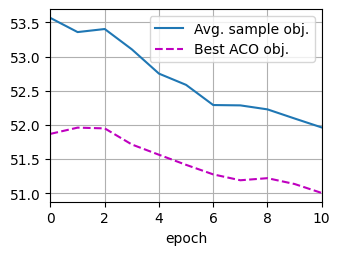

In [3]:
n_node = 500
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

wandb: updating run metadata


total training duration: 973.3349792957306
epoch -1: (14.696833610534668, 13.415902495384216)
epoch 0: (14.527983367443085, 13.388869643211365)
epoch 1: (14.261627614498138, 13.439322292804718)
epoch 2: (13.964377105236053, 13.731857895851135)
epoch 3: (14.049014925956726, 13.812006115913391)
epoch 4: (14.03019654750824, 13.810312747955322)
epoch 5: (14.04482227563858, 13.824581146240234)
epoch 6: (14.053450286388397, 13.802338182926178)
epoch 7: (14.025629997253418, 13.822080850601196)
epoch 8: (14.054791390895844, 13.820873737335205)
epoch 9: (14.046438336372375, 13.801750540733337)


wandb: uploading wandb-summary.json; uploading config.yaml


wandb: uploading history steps 319-319, summary


wandb: 
wandb: Run history:
wandb:  train/avg_cost ▃▅▄▅▃▃▄█▅▃▂▃▄▂▃▂▂▁▄▃▁▂▄▂▄▃▆▃▃▃▄▂▄▂▅▃▃▄▄▂
wandb: train/best_cost ▃▄▄▅▃▄▅▃▁▄▆▄▆▅▆▄▅▅▄▂▆▃▃▄█▇▅▅▄▇▃▅▅▅▅▄▅▅▅▂
wandb:     train/epoch ▁▁▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇████
wandb: 
wandb: Run summary:
wandb:  train/avg_cost 14.44617
wandb: train/best_cost 14.17673
wandb:     train/epoch 9
wandb: 


wandb: 🚀 View run cvrp100 at: https://wandb.ai/shoraaa-vnu/claco/runs/vyvmzyn8
wandb: ⭐️ View project at: https://wandb.ai/shoraaa-vnu/claco
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260118_173337-vyvmzyn8/logs


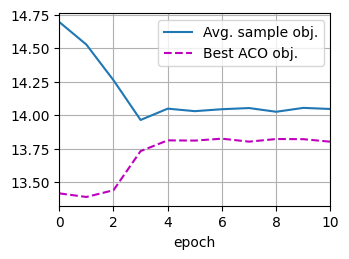

In [4]:

n_node = 100
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

wandb: updating run metadata


total training duration: 1423.570778131485
epoch -1: (99.38769054412842, 97.8438835144043)
epoch 0: (99.34159564971924, 97.88415431976318)
epoch 1: (99.35428714752197, 97.86226272583008)
epoch 2: (99.13522624969482, 97.70074796676636)
epoch 3: (98.78158473968506, 97.37468147277832)
epoch 4: (98.36505031585693, 97.17351055145264)
epoch 5: (98.2241358757019, 97.0516676902771)
epoch 6: (97.93764543533325, 96.81030321121216)
epoch 7: (97.73978805541992, 96.66370344161987)
epoch 8: (97.90182733535767, 96.6912293434143)
epoch 9: (97.92536973953247, 96.62561511993408)


wandb: uploading wandb-summary.json


wandb: uploading config.yaml


wandb: uploading history steps 319-319, summary


wandb: 
wandb: Run history:
wandb:  train/avg_cost ▆▇▆▆▇▄▆▄▄▆▆▅▆█▆▅▄▅▅▆▄▅▂▆▅▇▁▄▄▆▄▅▆▃▄▄▆▄▃▄
wandb: train/best_cost ▅▅▅▅▄▆▅▅▆█▃▄▄▅▇▆▅▃▄▅▃▄▄▃▂▄▄▄▁▄▃▅▅▆▆▃▅▄▆▅
wandb:     train/epoch ▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇████
wandb: 
wandb: Run summary:
wandb:  train/avg_cost 97.37885
wandb: train/best_cost 96.10694
wandb:     train/epoch 9
wandb: 


wandb: 🚀 View run cvrp1000 at: https://wandb.ai/shoraaa-vnu/claco/runs/6dcyhu5i
wandb: ⭐️ View project at: https://wandb.ai/shoraaa-vnu/claco
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260118_175132-6dcyhu5i/logs


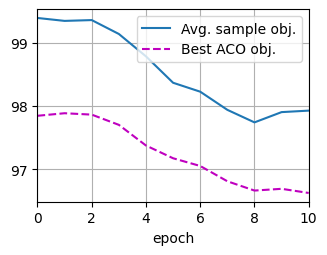

In [5]:
n_node = 1000
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

In [6]:
# n_nod  , k_sparse, n_ants, steps_per_epoch, epochs, True)

wandb: updating run metadata


total training duration: 3825.751496076584
epoch -1: (442.6104030609131, 441.2416744232178)
epoch 0: (441.5944194793701, 440.2905750274658)
epoch 1: (441.1138973236084, 439.91785621643066)
epoch 2: (440.19797134399414, 439.0922145843506)
epoch 3: (438.411828994751, 437.3290767669678)
epoch 4: (437.0528926849365, 436.1230239868164)
epoch 5: (436.85711669921875, 436.00827980041504)
epoch 6: (436.43586349487305, 435.5449905395508)
epoch 7: (436.76568603515625, 435.9642734527588)
epoch 8: (436.4120330810547, 435.58452224731445)
epoch 9: (436.31386947631836, 435.49661445617676)


wandb: uploading wandb-summary.json


wandb: uploading wandb-summary.json; uploading config.yaml


wandb: uploading history steps 319-319, summary


wandb: 
wandb: Run history:
wandb:  train/avg_cost ▇▇▅▇█▆▃█▇▆▇▇▇▇▅▅▅▅▃▅▄▅▃▃▅▄▄▁▃▃▇▅▅▄▇▃▂▁▃▇
wandb: train/best_cost ▇█▅▅▆▅▄▅█▅▇▅▇▅█▇▄▆▃▃▆▆▅▄▁▆▆▃▄▃▆▂▇▅▅▅▃▆▄▇
wandb:     train/epoch ▁▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▇█████
wandb: 
wandb: Run summary:
wandb:  train/avg_cost 433.92404
wandb: train/best_cost 433.12384
wandb:     train/epoch 9
wandb: 


wandb: 🚀 View run cvrp5000 at: https://wandb.ai/shoraaa-vnu/claco/runs/pbrvq2dr
wandb: ⭐️ View project at: https://wandb.ai/shoraaa-vnu/claco
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260118_181924-pbrvq2dr/logs


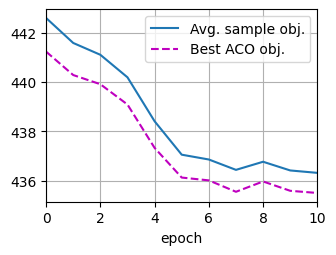

In [7]:
n_node = 5000
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

In [ ]:
n_node = 10000
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)